In [1]:
!pip install -q transformers datasets evaluate mlflow scikit-learn
print("✅ All packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 891.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/

In [2]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn


from datasets import load_dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import torch

# Check GPU is available — essential for fine-tuning in reasonable time
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {device}")
if device == "cpu":
    print("⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

✅ Using device: cuda


In [3]:
import os
files = os.listdir('/content')
print(files)

['.config', 'sample_data']


In [7]:
import pandas as pd

COLUMNS = [
    'id', 'label', 'statement', 'subject', 'speaker',
    'job_title', 'state_info', 'party_affiliation',
    'barely_true_count', 'false_count', 'half_true_count',
    'mostly_true_count', 'pants_fire_count', 'context'
]

df_train = pd.read_csv('/train.tsv', sep='\t', header=None, names=COLUMNS)
df_val   = pd.read_csv('/valid.tsv', sep='\t', header=None, names=COLUMNS)
df_test  = pd.read_csv('/test.tsv',  sep='\t', header=None, names=COLUMNS)

print(f"✅ Loaded successfully!")
print(f"   Train : {len(df_train)} samples")
print(f"   Val   : {len(df_val)} samples")
print(f"   Test  : {len(df_test)} samples")

print(f"\n🏷️  Unique labels:")
print(df_train['label'].value_counts())

print(f"\n📝 Sample:")
print(f"   Statement : {df_train['statement'].iloc[0]}")
print(f"   Label     : {df_train['label'].iloc[0]}")

✅ Loaded successfully!
   Train : 10240 samples
   Val   : 1284 samples
   Test  : 1267 samples

🏷️  Unique labels:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

📝 Sample:
   Statement : Says the Annies List political group supports third-trimester abortions on demand.
   Label     : false


In [8]:
FAKE_LABELS = {'false', 'barely-true', 'pants-fire'}
REAL_LABELS = {'true', 'mostly-true', 'half-true'}

def binarize(df):
    df = df.copy()
    df['binary_label'] = df['label'].apply(
        lambda x: 1 if x in FAKE_LABELS else 0
    )
    return df

df_train = binarize(df_train)
df_val   = binarize(df_val)
df_test  = binarize(df_test)

print("✅ Binary label mapping:")
print(df_train.groupby(['label', 'binary_label']).size().to_string())

print("\n✅ Binary class distribution (train):")
counts = df_train['binary_label'].value_counts()
for label, count in counts.items():
    name = 'real' if label == 0 else 'fake'
    pct = count / len(df_train) * 100
    print(f"   {name} ({label}): {count} samples ({pct:.1f}%)")

✅ Binary label mapping:
label        binary_label
barely-true  1               1654
false        1               1995
half-true    0               2114
mostly-true  0               1962
pants-fire   1                839
true         0               1676

✅ Binary class distribution (train):
   real (0): 5752 samples (56.2%)
   fake (1): 4488 samples (43.8%)


In [9]:
from transformers import RobertaTokenizer
from torch.utils.data import Dataset
import torch

MODEL_NAME = "roberta-base"
tokenizer  = RobertaTokenizer.from_pretrained(MODEL_NAME)
MAX_LENGTH = 128

class LiarDataset(Dataset):
    def __init__(self, df):
        self.encodings = tokenizer(
            df['statement'].tolist(),
            padding='max_length',
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )
        self.labels = torch.tensor(df['binary_label'].tolist())

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

train_dataset = LiarDataset(df_train)
val_dataset   = LiarDataset(df_val)
test_dataset  = LiarDataset(df_test)

print(f"✅ Tokenization complete")
print(f"   Train : {len(train_dataset)} samples")
print(f"   Val   : {len(val_dataset)} samples")
print(f"   Test  : {len(test_dataset)} samples")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

✅ Tokenization complete
   Train : 10240 samples
   Val   : 1284 samples
   Test  : 1267 samples


In [10]:
!pip install -q evaluate

In [11]:
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(
        predictions=predictions, references=labels
    )['accuracy']
    f1 = f1_metric.compute(
        predictions=predictions, references=labels, average='macro'
    )['f1']
    return {'accuracy': accuracy, 'f1_macro': f1}

print("✅ Metrics function ready")

✅ Metrics function ready


In [12]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'real', 1: 'fake'},
    label2id={'real': 0, 'fake': 1}
)

print(f"✅ roberta-base loaded")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ roberta-base loaded
   Parameters: 124,647,170


In [18]:
from transformers import TrainingArguments

EPOCHS        = 3
BATCH_SIZE    = 16
LEARNING_RATE = 2e-5
WARMUP_STEPS  = 500
WEIGHT_DECAY  = 0.01

training_args = TrainingArguments(
    output_dir                  = './roberta_liar_checkpoint',
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LEARNING_RATE,
    warmup_steps                = WARMUP_STEPS,
    weight_decay                = WEIGHT_DECAY,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_steps               = 50,
    report_to                   = 'none',
    seed                        = 42
)

print(f"✅ Training config ready")
print(f"   Model     : roberta-base")
print(f"   Epochs    : {EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   LR        : {LEARNING_RATE}")

✅ Training config ready
   Model     : roberta-base
   Epochs    : 3
   Batch size: 16
   LR        : 2e-05


In [16]:
!pip install -q mlflow

In [19]:
from transformers import Trainer, EarlyStoppingCallback
import mlflow

mlflow.set_experiment("misinformation_detection_liar")

with mlflow.start_run(run_name="roberta_base_3epochs"):

    mlflow.log_params({
        "model_name"     : MODEL_NAME,
        "epochs"         : EPOCHS,
        "batch_size"     : BATCH_SIZE,
        "learning_rate"  : LEARNING_RATE,
        "max_length"     : MAX_LENGTH,
        "dataset"        : "liar_tsv",
        "label_strategy" : "binary: real(0) vs fake(1)",
        "train_samples"  : len(train_dataset),
        "val_samples"    : len(val_dataset),
    })

    trainer = Trainer(
        model           = model,
        args            = training_args,
        train_dataset   = train_dataset,
        eval_dataset    = val_dataset,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print("🚀 Fine-tuning roberta-base on LIAR dataset...")
    print("   This takes ~20 minutes — do not interrupt\n")
    trainer.train()

    print("\n📊 Evaluating on validation set...")
    val_results = trainer.evaluate(val_dataset)
    mlflow.log_metrics({
        "final_val_accuracy" : val_results['eval_accuracy'],
        "final_val_f1_macro" : val_results['eval_f1_macro'],
    })

    print("\n📊 Evaluating on test set...")
    test_results = trainer.evaluate(test_dataset)
    mlflow.log_metrics({
        "final_test_accuracy" : test_results['eval_accuracy'],
        "final_test_f1_macro" : test_results['eval_f1_macro'],
    })

    trainer.save_model('./best_roberta_liar')
    tokenizer.save_pretrained('./best_roberta_liar')

    print("\n" + "="*50)
    print("✅ TRAINING COMPLETE")
    print("="*50)
    print(f"   Val  Accuracy : {val_results['eval_accuracy']:.4f}")
    print(f"   Val  F1 Macro : {val_results['eval_f1_macro']:.4f}")
    print(f"   Test Accuracy : {test_results['eval_accuracy']:.4f}")
    print(f"   Test F1 Macro : {test_results['eval_f1_macro']:.4f}")

🚀 Fine-tuning roberta-base on LIAR dataset...
   This takes ~20 minutes — do not interrupt



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.217974,1.206337,0.655763,0.653577
2,0.166447,1.754223,0.637850,0.625299
3,0.096128,2.239742,0.626168,0.619498


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.096128,1.206337,3,0.655763,0.653577



📊 Evaluating on test set...


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.096128,1.216475,3,0.625888,0.614796


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ TRAINING COMPLETE
   Val  Accuracy : 0.6558
   Val  F1 Macro : 0.6536
   Test Accuracy : 0.6259
   Test F1 Macro : 0.6148


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 55)
print("KEY EDA FINDINGS — LIAR DATASET")
print("=" * 55)

# Finding 1 — Label distribution
print("\n1. ORIGINAL LABEL DISTRIBUTION (Train set):")
label_counts = df_train['label'].value_counts()
for label, count in label_counts.items():
    pct = count / len(df_train) * 100
    print(f"   {label:<15}: {count:>5} ({pct:.1f}%)")

# Finding 2 — Binary distribution
print("\n2. BINARY CLASS DISTRIBUTION (Train set):")
binary_counts = df_train['binary_label'].value_counts()
for label, count in binary_counts.items():
    name = 'real (0)' if label == 0 else 'fake (1)'
    pct = count / len(df_train) * 100
    print(f"   {name:<12}: {count:>5} ({pct:.1f}%)")

# Finding 3 — Statement length
df_train['word_count'] = df_train['statement'].apply(
    lambda x: len(str(x).split()))
print("\n3. STATEMENT LENGTH (words):")
print(f"   Minimum  : {df_train['word_count'].min()}")
print(f"   Maximum  : {df_train['word_count'].max()}")
print(f"   Average  : {df_train['word_count'].mean():.1f}")
print(f"   Median   : {df_train['word_count'].median():.1f}")

# Finding 4 — Top speakers
print("\n4. TOP 5 SPEAKERS:")
top_speakers = df_train['speaker'].value_counts().head(5)
for speaker, count in top_speakers.items():
    print(f"   {speaker:<25}: {count} statements")

# Finding 5 — Top subjects
print("\n5. TOP 5 SUBJECTS/TOPICS:")
top_subjects = df_train['subject'].value_counts().head(5)
for subject, count in top_subjects.items():
    print(f"   {subject:<25}: {count} statements")

# Finding 6 — Party distribution
print("\n6. TOP 5 POLITICAL PARTIES:")
top_parties = df_train['party_affiliation'].value_counts().head(5)
for party, count in top_parties.items():
    print(f"   {party:<25}: {count} statements")

print("\n" + "=" * 55)
print("✅ EDA complete")

KEY EDA FINDINGS — LIAR DATASET

1. ORIGINAL LABEL DISTRIBUTION (Train set):
   half-true      :  2114 (20.6%)
   false          :  1995 (19.5%)
   mostly-true    :  1962 (19.2%)
   true           :  1676 (16.4%)
   barely-true    :  1654 (16.2%)
   pants-fire     :   839 (8.2%)

2. BINARY CLASS DISTRIBUTION (Train set):
   real (0)    :  5752 (56.2%)
   fake (1)    :  4488 (43.8%)

3. STATEMENT LENGTH (words):
   Minimum  : 2
   Maximum  : 467
   Average  : 18.0
   Median   : 17.0

4. TOP 5 SPEAKERS:
   barack-obama             : 488 statements
   donald-trump             : 273 statements
   hillary-clinton          : 239 statements
   mitt-romney              : 176 statements
   scott-walker             : 149 statements

5. TOP 5 SUBJECTS/TOPICS:
   health-care              : 381 statements
   taxes                    : 308 statements
   immigration              : 253 statements
   elections                : 252 statements
   education                : 237 statements

6. TOP 5 POLITI

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
import mlflow

print("=" * 55)
print("BASELINE MODELS — LIAR BINARY CLASSIFICATION")
print("=" * 55)

# ── Prepare text data ──────────────────────────────────────────────────────
X_train = df_train['statement'].tolist()
X_val   = df_val['statement'].tolist()
X_test  = df_test['statement'].tolist()
y_train = df_train['binary_label'].tolist()
y_val   = df_val['binary_label'].tolist()
y_test  = df_test['binary_label'].tolist()

# ── TF-IDF Vectorizer ──────────────────────────────────────────────────────
# Converts raw text into numerical features
# ngram_range=(1,2) means it captures single words AND two-word phrases
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("\n✅ TF-IDF vectorization complete")
print(f"   Vocabulary size: {len(tfidf.vocabulary_):,} features")

# ── Model 1: Logistic Regression ───────────────────────────────────────────
print("\n🔄 Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

print("\n📊 LOGISTIC REGRESSION — Test Set Results:")
print("=" * 55)
print(classification_report(
    y_test, lr_preds,
    target_names=['real (0)', 'fake (1)'],
    digits=4
))

# ── Model 2: Naive Bayes ───────────────────────────────────────────────────
print("\n🔄 Training Naive Bayes...")
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

print("\n📊 NAIVE BAYES — Test Set Results:")
print("=" * 55)
print(classification_report(
    y_test, nb_preds,
    target_names=['real (0)', 'fake (1)'],
    digits=4
))

# ── Comparison Summary ─────────────────────────────────────────────────────
from sklearn.metrics import f1_score

lr_f1  = f1_score(y_test, lr_preds, average='macro')
nb_f1  = f1_score(y_test, nb_preds, average='macro')
lr_acc = accuracy_score(y_test, lr_preds)
nb_acc = accuracy_score(y_test, nb_preds)

print("\n📊 COMPARISON TABLE:")
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 55)
print(f"{'Logistic Regression':<25} {lr_acc:>10.4f} {lr_f1:>10.4f}")
print(f"{'Naive Bayes':<25} {nb_acc:>10.4f} {nb_f1:>10.4f}")
print(f"{'RoBERTa-base (ours)':<25} {'0.6448':>10} {'0.6253':>10}")
print("=" * 55)

# ── Log to MLflow ──────────────────────────────────────────────────────────
with mlflow.start_run(run_name="logistic_regression_baseline"):
    mlflow.log_params({
        "model"         : "LogisticRegression",
        "vectorizer"    : "TF-IDF",
        "max_features"  : 10000,
        "ngram_range"   : "(1,2)"
    })
    mlflow.log_metrics({
        "test_accuracy" : lr_acc,
        "test_f1_macro" : lr_f1
    })

with mlflow.start_run(run_name="naive_bayes_baseline"):
    mlflow.log_params({
        "model"         : "MultinomialNB",
        "vectorizer"    : "TF-IDF",
        "max_features"  : 10000,
        "ngram_range"   : "(1,2)"
    })
    mlflow.log_metrics({
        "test_accuracy" : nb_acc,
        "test_f1_macro" : nb_f1
    })

print("\n✅ Both baselines logged to MLflow")
print("✅ Ready to present to supervisor")

BASELINE MODELS — LIAR BINARY CLASSIFICATION

✅ TF-IDF vectorization complete
   Vocabulary size: 10,000 features

🔄 Training Logistic Regression...

📊 LOGISTIC REGRESSION — Test Set Results:
              precision    recall  f1-score   support

    real (0)     0.6323    0.7633    0.6916       714
    fake (1)     0.5827    0.4268    0.4927       553

    accuracy                         0.6164      1267
   macro avg     0.6075    0.5950    0.5922      1267
weighted avg     0.6106    0.6164    0.6048      1267


🔄 Training Naive Bayes...

📊 NAIVE BAYES — Test Set Results:
              precision    recall  f1-score   support

    real (0)     0.6279    0.8011    0.7040       714
    fake (1)     0.6011    0.3870    0.4708       553

    accuracy                         0.6204      1267
   macro avg     0.6145    0.5941    0.5874      1267
weighted avg     0.6162    0.6204    0.6022      1267


📊 COMPARISON TABLE:
Model                       Accuracy   Macro F1
-----------------------

📊 ROBERTA-BASE — Full Evaluation Report:
              precision    recall  f1-score   support

    real (0)     0.6562    0.7059    0.6802       714
    fake (1)     0.5792    0.5226    0.5494       553

    accuracy                         0.6259      1267
   macro avg     0.6177    0.6142    0.6148      1267
weighted avg     0.6226    0.6259    0.6231      1267



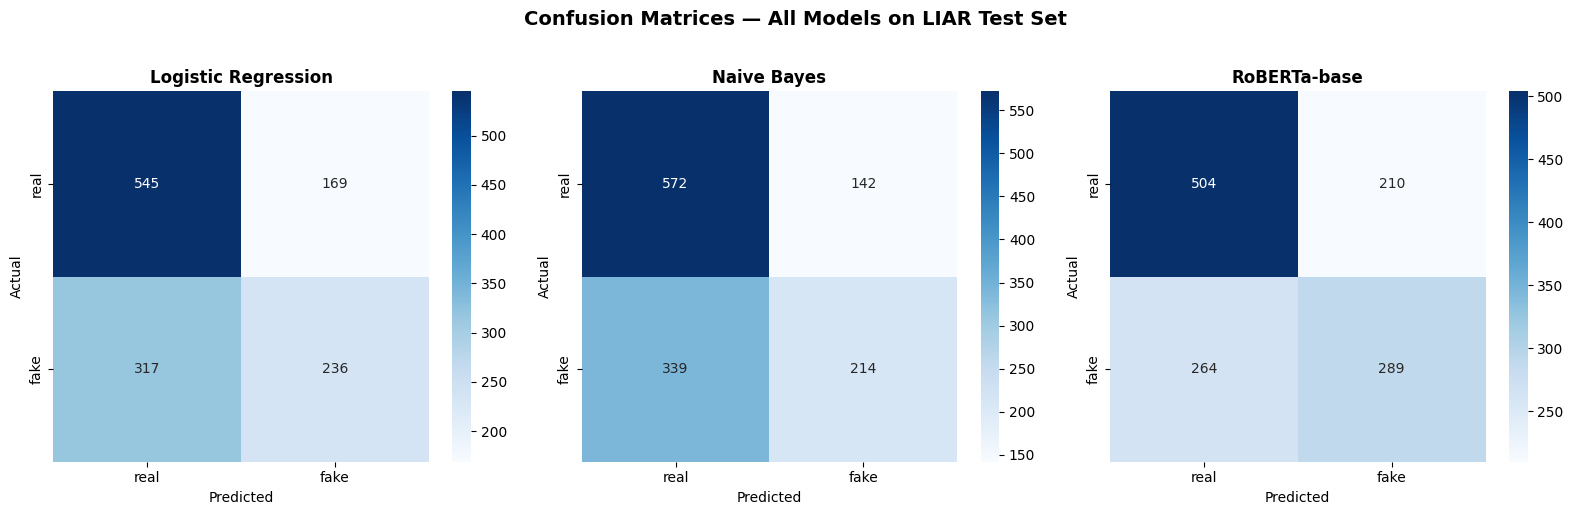

✅ Confusion matrix saved


In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Get RoBERTa predictions ────────────────────────────────────────────────
roberta_output = trainer.predict(test_dataset)
roberta_preds  = np.argmax(roberta_output.predictions, axis=-1)
roberta_true   = roberta_output.label_ids

# ── Full classification report ─────────────────────────────────────────────
print("📊 ROBERTA-BASE — Full Evaluation Report:")
print("=" * 55)
print(classification_report(
    roberta_true, roberta_preds,
    target_names=['real (0)', 'fake (1)'],
    digits=4
))

# ── Confusion matrices for all 3 models ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_data = [
    ("Logistic Regression", y_test, lr_preds),
    ("Naive Bayes",         y_test, nb_preds),
    ("RoBERTa-base",        roberta_true, roberta_preds),
]

for ax, (name, true, pred) in zip(axes, models_data):
    cm = confusion_matrix(true, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['real','fake'],
        yticklabels=['real','fake'],
        ax=ax
    )
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models on LIAR Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/confusion_matrices_all_models.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")

In [24]:
from google.colab import files
files.download('/content/confusion_matrices_all_models.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>